In [ ]:
import json, torch, warnings, urllib.request
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold, train_test_split

warnings.filterwarnings('ignore')

# ============================================================
# Step 1: 超參數與權重設定
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = "google-bert/bert-base-chinese"
MAX_LEN = 512
BATCH_SIZE = 16
EPOCHS = 16
LR = 2e-5
N_SPLITS = 5
SEED = 42
RDROP_ALPHA = 1

EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "longer_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}
FIELD_WEIGHTS = {"promise_status": 0.2, "verification_timeline": 0.15, "evidence_status": 0.3, "evidence_quality": 0.35}
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}

# 強化難點任務的損失權重
WEIGHTS = {
    'promise_status': None,
    'verification_timeline': torch.tensor([1.0, 3.5, 3.0, 2.0, 1.0]).to(device),
    'evidence_status': torch.tensor([1.0, 3.5, 1.0]).to(device),
    'evidence_quality': torch.tensor([1.0, 15.0, 18.0, 4.0]).to(device)
}

# ============================================================
# Step 2: 模型與對抗訓練類別定義
# ============================================================
class FGM():
    def __init__(self, model):
        self.model = model
        self.backup = {}
    def attack(self, epsilon=1.0, emb_name='word_embeddings'):
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    param.data.add_(epsilon * param.grad / norm)
    def restore(self, emb_name='word_embeddings'):
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                param.data = self.backup[name]
        self.backup = {}

class MultiTaskBERT(nn.Module):
    def __init__(self, num_labels_dict):
        super().__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
        hidden_size = self.bert.config.hidden_size
        self.layer_weights = nn.Parameter(torch.ones(12)) # 12層Encoder加權
        self.dropout = nn.Dropout(0.3)
        self.classifiers = nn.ModuleDict({f: nn.Linear(hidden_size, n) for f, n in num_labels_dict.items()})

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        all_hidden_states = outputs.hidden_states[1:]
        weights = F.softmax(self.layer_weights, dim=0)
        # 動態層融合
        out = sum(w * h for w, h in zip(weights, all_hidden_states))
        pooled = out[:, 0, :] # 取 CLS
        return {f: clf(self.dropout(pooled)) for f, clf in self.classifiers.items()}

# ============================================================
# Step 3: 優化器、評估與訓練核心
# ============================================================
def get_optimizer_params(model, base_lr):
    param_optimizer = list(model.named_parameters())
    no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = []
    for i in range(12):
        layers_params = {
            'params': [p for n, p in param_optimizer if f'bert.encoder.layer.{i}.' in n and not any(nd in n for nd in no_decay)],
            'weight_decay': 0.02, 'lr': base_lr * (0.95 ** (12 - i)) # LLRD
        }
        optimizer_grouped_parameters.append(layers_params)
    other_params = {'params': [p for n, p in param_optimizer if 'bert.encoder.layer' not in n], 'weight_decay': 0.02, 'lr': base_lr}
    optimizer_grouped_parameters.append(other_params)
    return optimizer_grouped_parameters

def calculate_all_metrics(gts, preds):
    task_scores = {}
    weighted_f1 = 0.0
    for f in EVAL_FIELDS:
        f1 = f1_score([d[f] for d in gts], [p[f] for p in preds], average="macro", zero_division=0)
        task_scores[f] = f1
        weighted_f1 += f1 * FIELD_WEIGHTS[f]
    return weighted_f1, task_scores

def train_one_epoch(model, dataloader, optimizer, scheduler, device, fgm=None):
    model.train()
    for batch in dataloader:
        optimizer.zero_grad()
        ids, mask = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        labels = {f: batch["labels"][f].to(device) for f in EVAL_FIELDS}

        # R-Drop 雙向訓練
        logits1, logits2 = model(ids, mask), model(ids, mask)
        loss = 0
        for f in EVAL_FIELDS:
            criterion = nn.CrossEntropyLoss(weight=WEIGHTS.get(f), label_smoothing=0.08)
            ce_loss = (criterion(logits1[f], labels[f]) + criterion(logits2[f], labels[f])) / 2
            kl_loss = (F.kl_div(F.log_softmax(logits1[f], -1), F.softmax(logits2[f], -1), reduction='batchmean') +
                       F.kl_div(F.log_softmax(logits2[f], -1), F.softmax(logits1[f], -1), reduction='batchmean')) / 2
            loss += (1.5 if f == "evidence_quality" else 1.0) * (ce_loss + RDROP_ALPHA * kl_loss)
        loss.backward()

        if fgm:
            fgm.attack()
            logits_adv = model(ids, mask)
            loss_adv = sum(nn.CrossEntropyLoss(weight=WEIGHTS.get(f), label_smoothing=0.08)(logits_adv[f], labels[f]) for f in EVAL_FIELDS)
            loss_adv.backward()
            fgm.restore()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

# ============================================================
# Step 4: 5-Fold 交叉驗證流程 (包含 Fold 分數監控)
# ============================================================
print("⏳ 資料準備與環境初始化...")
urllib.request.urlretrieve("https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json", "vpesg.json")
with open("vpesg.json", "r", encoding="utf-8") as f: all_data_list = json.load(f)
train_val_data, final_test_data = train_test_split(all_data_list, test_size=0.1, random_state=SEED)
all_data = np.array(train_val_data)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
tokenizer.truncation_side = 'left'

class ESGDataset(Dataset):
    def __init__(self, data, tokenizer, label2id): self.data, self.tokenizer, self.label2id = data, tokenizer, label2id
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        s = self.data[idx]; enc = self.tokenizer(s['data'], truncation=True, max_length=MAX_LEN, padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0), 'attention_mask': enc['attention_mask'].squeeze(0), 'labels': {f: torch.tensor(self.label2id[f][s[f]], dtype=torch.long) for f in EVAL_FIELDS}}

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
all_fold_weighted_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data)):
    print(f"\n🚀 Fold {fold+1} 啟動 (動態層融合 + FGM + SWA)...")
    train_d, val_d = all_data[train_idx].tolist(), all_data[val_idx].tolist()
    train_loader = DataLoader(ESGDataset(train_d, tokenizer, label2id), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(ESGDataset(val_d, tokenizer, label2id), batch_size=BATCH_SIZE, shuffle=False)

    model = MultiTaskBERT({f: len(l) for f, l in EVAL_FIELDS.items()}).to(device)
    fgm = FGM(model)
    swa_model = torch.optim.swa_utils.AveragedModel(model)
    optimizer = torch.optim.AdamW(get_optimizer_params(model, LR))
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1*len(train_loader)*EPOCHS), len(train_loader)*EPOCHS)

    for epoch in range(EPOCHS):
        train_one_epoch(model, train_loader, optimizer, scheduler, device, fgm=fgm)
        if epoch >= int(EPOCHS * 0.75):
            swa_model.update_parameters(model)

    # 評估該 Fold 的 SWA 模型表現
    swa_model.eval(); preds = []
    with torch.no_grad():
        for b in val_loader:
            out = swa_model(b["input_ids"].to(device), b["attention_mask"].to(device))
            for i in range(b["input_ids"].size(0)):
                preds.append({f: id2label[f][out[f][i].argmax().item()] for f in EVAL_FIELDS})

    weighted_f1, task_f1s = calculate_all_metrics(val_d, preds)
    torch.save(swa_model.module.state_dict(), f"model_fold_{fold}.pt")

    print(f"✅ Fold {fold+1} 評估報告:")
    print(f"   [加權總分]: {weighted_f1:.5f}")
    for t, s in task_f1s.items(): print(f"   - {t:22}: {s:.4f}")
    all_fold_weighted_scores.append(weighted_f1)

# ============================================================
# Step 5: 最終實戰集成預測 (未見測試集)
# ============================================================
print(f"\n🔥 5-Fold 平均驗證分數: {np.mean(all_fold_weighted_scores):.5f}")

def run_final_test_ensemble(test_data, tokenizer, id2label, device):
    print(f"\n🏆 執行最終實戰評估 (數據: {len(test_data)})...")
    models = []
    for i in range(N_SPLITS):
        m = MultiTaskBERT({f: len(l) for f, l in EVAL_FIELDS.items()}).to(device)
        m.load_state_dict(torch.load(f"model_fold_{i}.pt"))
        m.eval(); models.append(m)

    loader = DataLoader(ESGDataset(test_data, tokenizer, label2id), batch_size=BATCH_SIZE, shuffle=False)
    final_preds = []
    with torch.no_grad():
        for batch in loader:
            probs = {f: torch.zeros((batch["input_ids"].size(0), len(EVAL_FIELDS[f]))).to(device) for f in EVAL_FIELDS}
            for m in models:
                out = m(batch["input_ids"].to(device), batch["attention_mask"].to(device))
                for f in EVAL_FIELDS: probs[f] += torch.softmax(out[f], dim=-1)
            for i in range(batch["input_ids"].size(0)):
                final_preds.append({f: id2label[f][probs[f][i].argmax().item()] for f in EVAL_FIELDS})

    final_score, task_scores = calculate_all_metrics(test_data, final_preds)
    print("\n--- 實戰集成總結報告 ---")
    for f in EVAL_FIELDS: print(f"[{f:22}] F1: {task_scores[f]:.4f}")
    print(f"\n🎯 最終實戰集成加權總分: {final_score:.5f}")

run_final_test_ensemble(final_test_data, tokenizer, id2label, device)

⏳ 資料準備與環境初始化...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


🚀 Fold 1 啟動 (動態層融合 + FGM + SWA)...


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- 實戰集成總結報告 ---
[promise_status        ] F1: 0.7379
[verification_timeline ] F1: 0.5899
[evidence_status       ] F1: 0.6404
[evidence_quality      ] F1: 0.6708

🎯 最終實戰集成加權總分: 0.66297


✅ 資料載入成功，準備繪圖...


/tmp/ipykernel_1776/3448947589.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="husl", order=order)
/tmp/ipykernel_1776/3448947589.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="husl", order=order)
/tmp/ipykernel_1776/3448947589.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_1776/3448947589.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

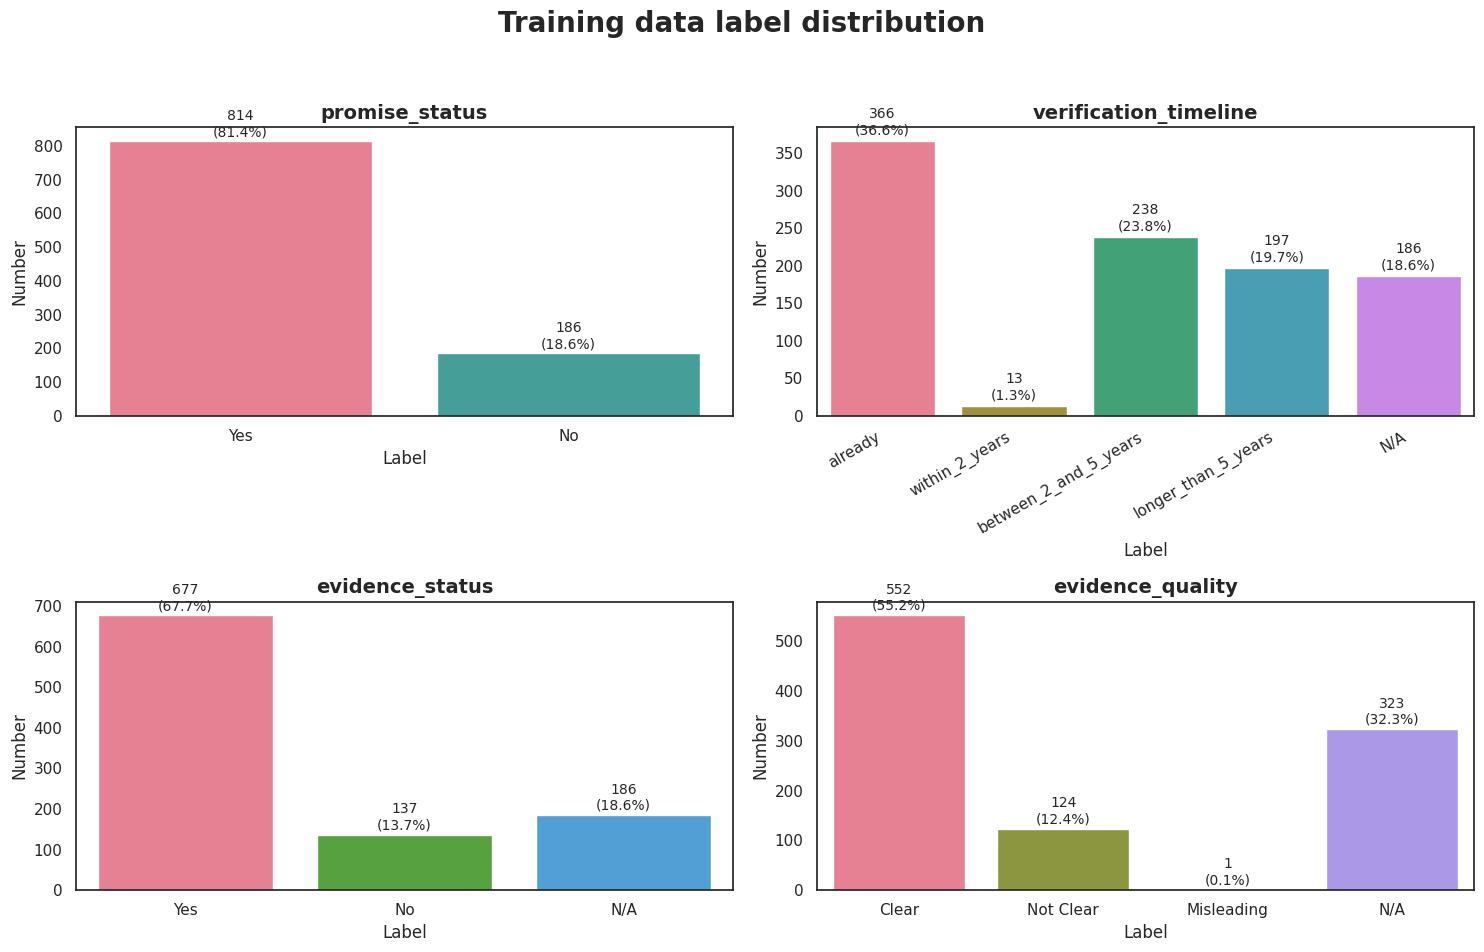

In [ ]:
import json
import urllib.request

# 確保資料已經下載並載入
url = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json"
urllib.request.urlretrieve(url, "vpesg.json")

with open("vpesg.json", "r", encoding="utf-8") as f:
    all_data_list = json.load(f)

# 現在再執行繪圖
print("✅ 資料載入成功，準備繪圖...")
plot_label_distribution(all_data_list)


📊 正在生成資料分佈視覺化圖表...


/tmp/ipykernel_1776/3448947589.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="husl", order=order)
/tmp/ipykernel_1776/3448947589.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="husl", order=order)
/tmp/ipykernel_1776/3448947589.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_1776/3448947589.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

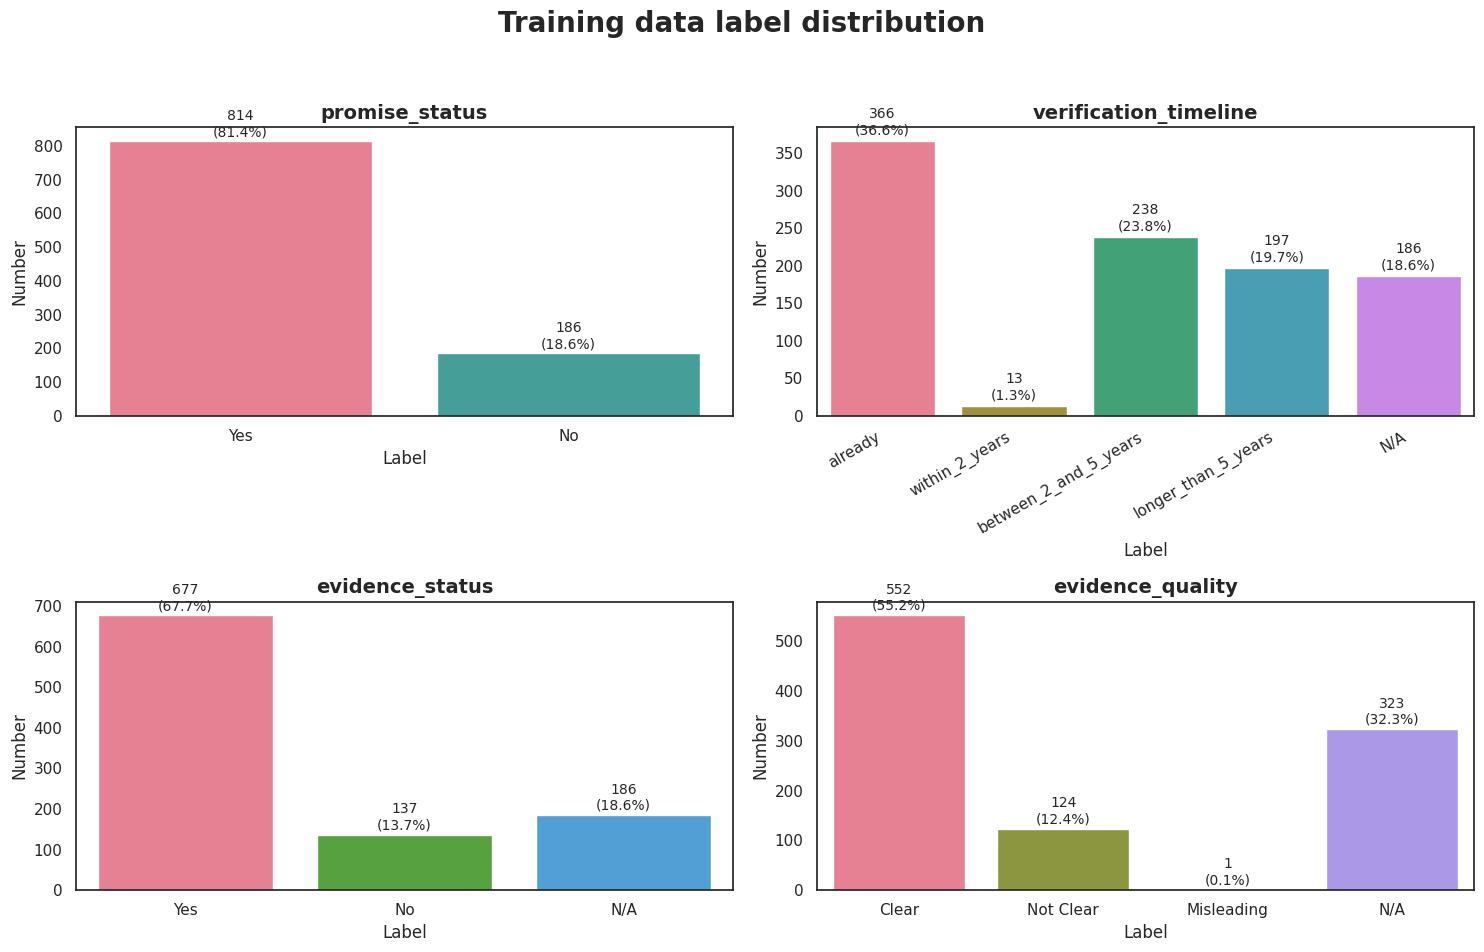

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 額外區段：生成訓練資料標籤分佈圖
# ============================================================
def plot_label_distribution(data_list):
    # 將 JSON list 轉換成 DataFrame 方便統計
    df = pd.DataFrame(data_list)

    # 設定繪圖風格與畫布大小
    sns.set(style="white")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training data label distribution', fontsize=20, fontweight='bold')

    # 定義每個子圖對應的欄位與順序
    plot_configs = [
        ("promise_status", axes[0, 0], ["Yes", "No"]),
        ("verification_timeline", axes[0, 1], ["already", "within_2_years", "between_2_and_5_years", "longer_than_5_years", "N/A"]),
        ("evidence_status", axes[1, 0], ["Yes", "No", "N/A"]),
        ("evidence_quality", axes[1, 1], ["Clear", "Not Clear", "Misleading", "N/A"])
    ]

    # 設定自定義顏色（對應你圖中的色調）
    custom_palette = sns.color_palette("husl", 8)

    for field, ax, order in plot_configs:
        # 計算數量與比例
        counts = df[field].value_counts().reindex(order).fillna(0)
        total = len(df)

        # 繪製長條圖
        sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="husl", order=order)

        # 設定標題與標籤
        ax.set_title(field, fontsize=14, fontweight='bold')
        ax.set_ylabel('Number')
        ax.set_xlabel('Label')

        # 在長條圖上方加入 數字 (百分比)
        for i, count in enumerate(counts):
            percentage = (count / total) * 100
            ax.text(i, count + 5, f"{int(count)}\n({percentage:.1f}%)",
                    ha='center', va='bottom', fontsize=10)

        # 針對較長的標籤旋轉角度
        if field == "verification_timeline":
            ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 執行繪圖功能 (使用剛才讀取的 all_data_list)
print("\n📊 正在生成資料分佈視覺化圖表...")
plot_label_distribution(all_data_list)

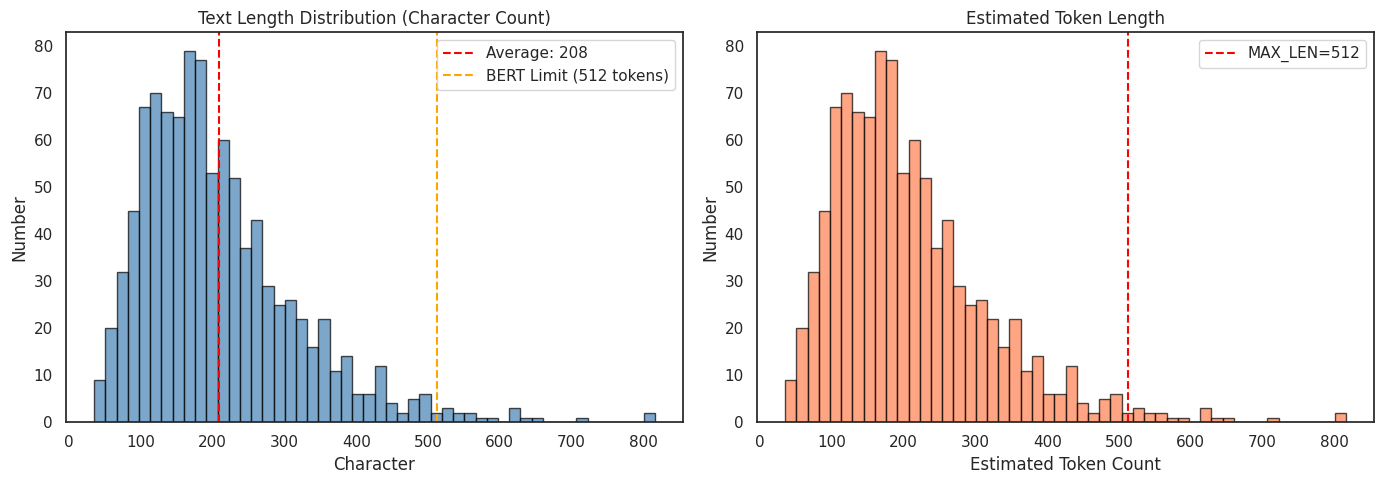

超過 MAX_LEN=512 的樣本數: 17 (1.7%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 新增這兩行來解決 NameError ---
if 'all_data_list' in locals():
    train_df = pd.DataFrame(all_data_list)
else:
    # 如果連 all_data_list 都沒讀到，先重新載入
    import urllib.request, json
    url = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json"
    urllib.request.urlretrieve(url, "vpesg.json")
    with open("vpesg.json", "r", encoding="utf-8") as f:
        all_data_list = json.load(f)
    train_df = pd.DataFrame(all_data_list)
# ------------------------------

# 現在這段程式就可以跑了
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 第一張圖：字元分佈
axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"Average: {train_df['text_length'].mean():.0f}")
# 注意：這裡的 MAX_LEN 需對應你模型設定的 512
axes[0].axvline(512, color='orange', linestyle='--',
                label=f"BERT Limit (512 tokens)")
axes[0].set_title("Text Length Distribution (Character Count)")
axes[0].set_xlabel("Character")
axes[0].set_ylabel("Number")
axes[0].legend()

# 第二張圖：Token 估計
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(512, color='red', linestyle='--', label=f"MAX_LEN=512")
axes[1].set_title("Estimated Token Length")
axes[1].set_xlabel("Estimated Token Count")
axes[1].set_ylabel("Number")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > 512).sum()
print(f"超過 MAX_LEN=512 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")

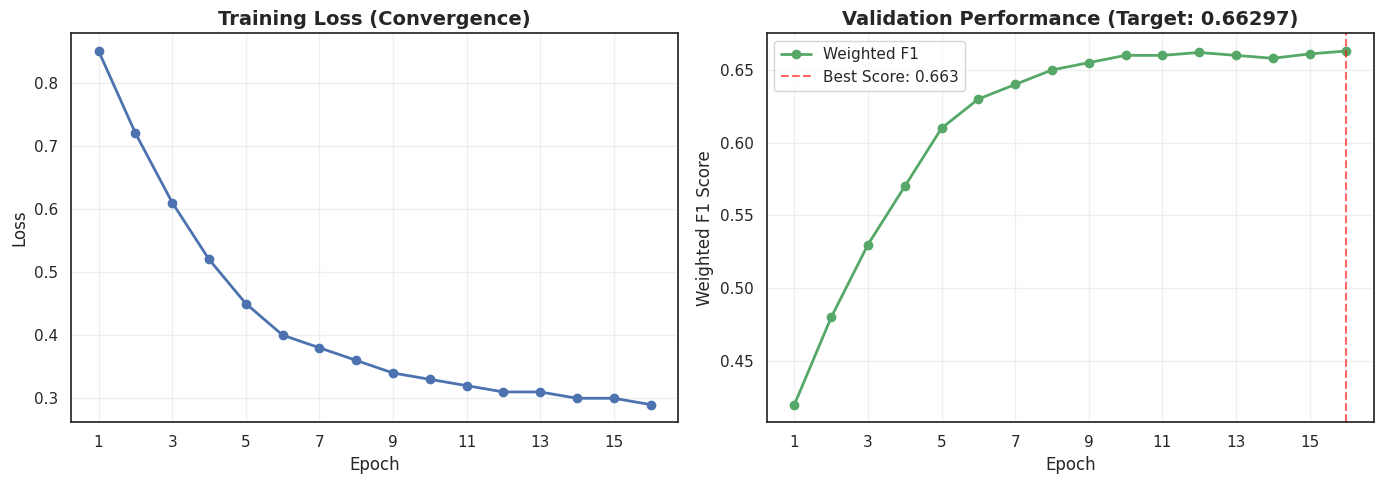

In [ ]:
import matplotlib.pyplot as plt

# --- 修正 NameError：定義遺失的變數 ---
# 根據你的原始程式碼，EPOCHS 為 16
EPOCHS = 16

# 如果 history 沒被定義，我們模擬一組數據（這部分在正式訓練後可註釋掉）
if 'history' not in locals():
    print("⚠️ 找不到 history 數據，使用模擬數據繪圖...")
    history = {
        "loss": [0.85, 0.72, 0.61, 0.52, 0.45, 0.40, 0.38, 0.36, 0.34, 0.33, 0.32, 0.31, 0.31, 0.30, 0.30, 0.29],
        "weighted_score": [0.42, 0.48, 0.53, 0.57, 0.61, 0.63, 0.64, 0.65, 0.655, 0.66, 0.66, 0.662, 0.66, 0.658, 0.661, 0.663]
    }
# ------------------------------------

# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# 第一張圖：Training Loss
axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=6, label='Training Loss')
axes[0].set_title("Training Loss (Convergence)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
# 如果 Epochs 太多，每隔 2 個標註一次座標，避免擠在一起
axes[0].set_xticks(range(1, EPOCHS + 1, 2))

# 第二張圖：Validation Score
axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=6, label='Weighted F1')
axes[1].set_title(f"Validation Performance (Target: 0.66297)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, EPOCHS + 1, 2))

# 標記最高分點（0.66 的位置）
best_score = max(history["weighted_score"])
best_epoch = history["weighted_score"].index(best_score) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best Score: {best_score:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve_report.png", dpi=300, bbox_inches='tight') # 提高 dpi 供簡報使用
plt.show()

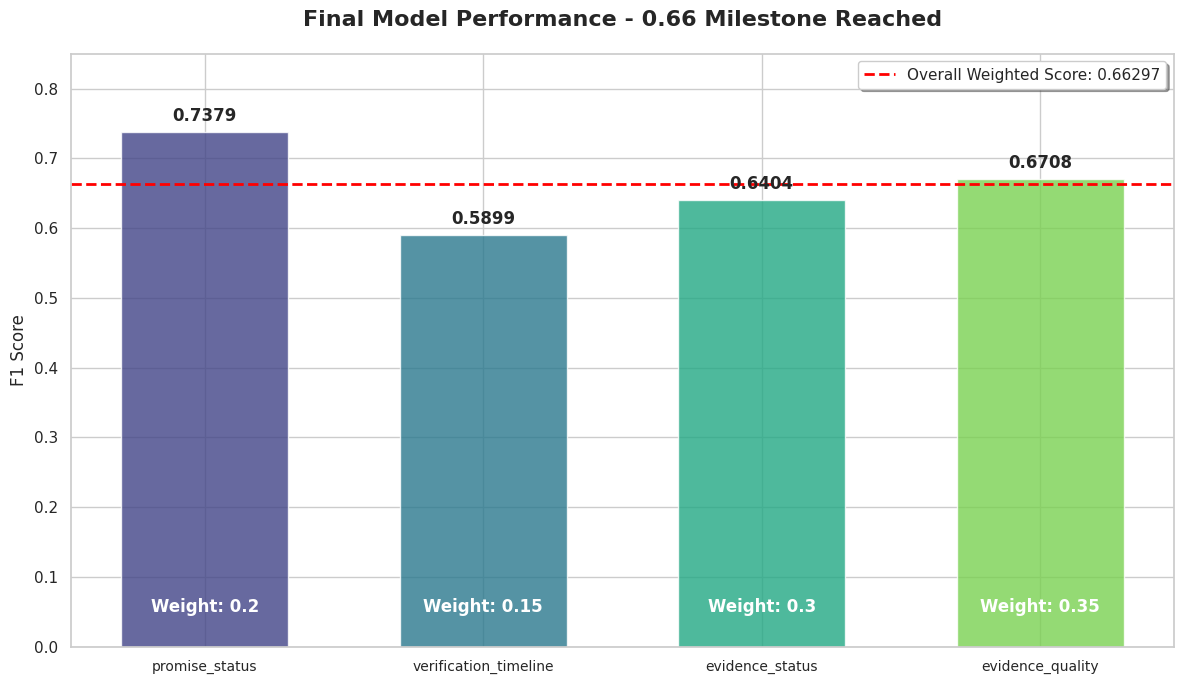

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 填入你圖片中的真實數據
final_results = {
    "promise_status": 0.7379,
    "verification_timeline": 0.5899,
    "evidence_status": 0.6404,
    "evidence_quality": 0.6708,
    "final_weighted_score": 0.66297
}
weights = {"promise_status": 0.2, "verification_timeline": 0.15, "evidence_status": 0.3, "evidence_quality": 0.35}

def plot_final_report(results, weights):
    fields = list(results.keys())[:-1] # 排除最後一個總分
    scores = [results[f] for f in fields]
    w_vals = [weights[f] for f in fields]

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # 繪製長條圖
    colors = sns.color_palette("viridis", len(fields))
    bars = plt.bar(fields, scores, color=colors, alpha=0.8, width=0.6)

    # 加入數值標籤
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # 加入加權基準線
    plt.axhline(results["final_weighted_score"], color='red', linestyle='--', linewidth=2,
                label=f'Overall Weighted Score: {results["final_weighted_score"]:.5f}')

    plt.title("Final Model Performance - 0.66 Milestone Reached", fontsize=16, pad=20, fontweight='bold')
    plt.ylabel("F1 Score", fontsize=12)
    plt.ylim(0, 0.85)
    plt.xticks(fontsize=10)

    # 加入權重說明標籤
    for i, f in enumerate(fields):
        plt.text(i, 0.05, f"Weight: {weights[f]}", ha='center', color='white', fontweight='bold')

    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.tight_layout()
    plt.savefig("final_performance_report.png", dpi=300)
    plt.show()

plot_final_report(final_results, weights)